# PCA
Note:  
* Used in exporatory analysis
* Visulize generic distance and relatedness between populations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
sns.set()

In [3]:
rnd_num=np.random.RandomState(42)
X=np.dot(rnd_num.rand(2,2),rnd_num.randn(2,500)).T

In [4]:
X

array([[-7.06275032e-01, -5.60911546e-01],
       [-5.50810755e-01, -4.63008578e-01],
       [ 2.82811768e-02,  8.01332565e-01],
       [-5.33973291e-01,  4.45221679e-02],
       [-1.29706786e-01, -3.14604522e-01],
       [-5.86785660e-01, -1.00304672e-01],
       [ 8.35586558e-02, -1.77307670e-01],
       [-2.22196567e-01, -3.70986829e-01],
       [-1.36546749e-01,  3.40666414e-02],
       [-1.57943397e+00, -1.94383023e+00],
       [-1.19439569e+00, -1.60791845e+00],
       [ 5.07562007e-01,  4.06303013e-02],
       [ 9.68832484e-02, -4.41507920e-01],
       [-8.11677523e-01, -3.55194597e-01],
       [-2.45654801e-01, -6.05201995e-01],
       [ 1.85390092e-01, -5.83973477e-01],
       [-1.03818322e+00,  7.34423846e-02],
       [ 4.32018026e-01,  1.60020305e-01],
       [-6.04673866e-01, -3.47255098e-01],
       [ 8.85096246e-03, -7.01313307e-01],
       [-9.29534570e-01, -8.55416426e-01],
       [-1.67438227e+00, -9.99313319e-01],
       [-1.97842115e+00, -1.81686241e+00],
       [ 1.

In [5]:
X[:,0]=-X[:,0]

(np.float64(-3.36000306145041),
 np.float64(3.3314115919910354),
 np.float64(-2.881825799615855),
 np.float64(4.1556598184440166))

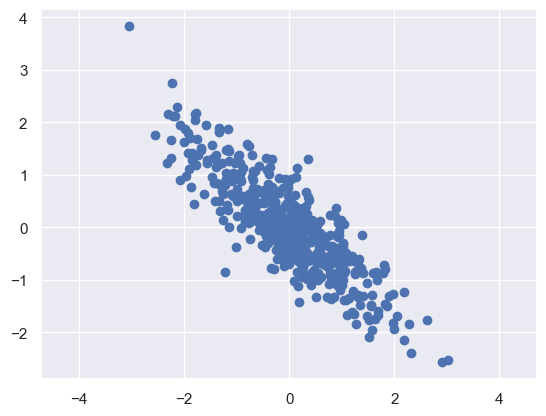

In [6]:
plt.scatter(X[:,0],X[:,1])
plt.axis('equal')

## Principal Components Identification

In [7]:
from sklearn.decomposition import PCA

In [8]:
pca=PCA(n_components=2)
pca.fit(X)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [9]:
print(pca.components_)

[[ 0.74062812 -0.67191517]
 [ 0.67191517  0.74062812]]


In [10]:
print(pca.explained_variance_)

[1.62123504 0.12581594]


In [11]:
print(pca.explained_variance_ratio_)

[0.92798382 0.07201618]


(np.float64(-3.36000306145041),
 np.float64(3.3314115919910354),
 np.float64(-2.881825799615855),
 np.float64(4.1556598184440166))

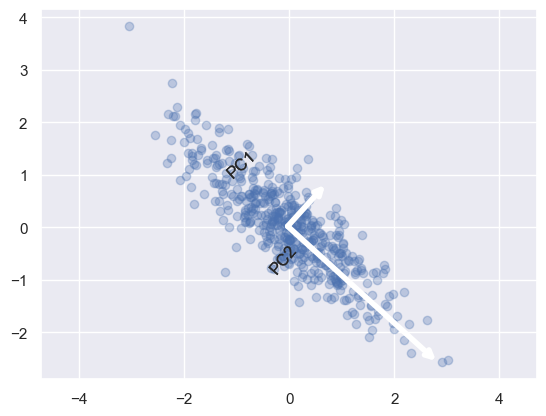

In [16]:
plt.scatter(X[:,0],X[:,1],alpha=0.3)

#plot data
for k,v in zip(pca.explained_variance_,pca.components_):
    vec=v*3*np.sqrt(k)

    ax=plt.gca()
    arrowprops=dict(arrowstyle='<-',
                    linewidth=4,
                    shrinkA=0,shrinkB=0)
    ax.annotate('',pca.mean_,pca.mean_+vec,arrowprops=arrowprops)
    ax.text(-0.90,1.2,'PC1',ha='center',va='center',rotation=42,size=12)
    ax.text(-0.1,-0.6,'PC2',ha='center',va='center',rotation=50,size=12)
plt.axis('equal')

### Dimensionality Reduction with PCA

In [18]:
pca=PCA(n_components=1)
pca.fit(X)
X_pca=pca.transform(X)

In [19]:
X.shape

(500, 2)

In [20]:
X_pca.shape

(500, 1)

(np.float64(-3.9188024367345236),
 np.float64(3.358021086052184),
 np.float64(-2.971613372818548),
 np.float64(4.159935417167954))

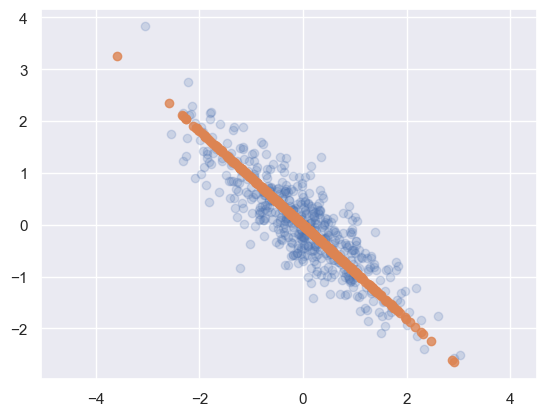

In [21]:
X_new=pca.inverse_transform(X_pca)
plt.scatter(X[:,0],X[:,1],alpha=0.2)
plt.scatter(X_new[:,0],X_new[:,1],alpha=0.8)
plt.axis('equal')

The light blue is Original data  
the orange is PCA  

---